In [ ]:
import zipfile
import os

zip_path = "/content/Caries_Dataset.zip"
extract_path = "/Caries_Dataset_extracted"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted to:", extract_path)

Dataset extracted to: /Caries_Dataset_extracted


In [ ]:
import os

extracted_dataset_path = "/Caries_Dataset_extracted"

# List contents of the extracted directory
print("Contents of the extracted dataset:")
for root, dirs, files in os.walk(extracted_dataset_path):
    level = root.replace(extracted_dataset_path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        print(f'{subindent}{f}')

Contents of the extracted dataset:
Caries_Dataset_extracted/
    NoEnamel_Caries/
        NoEnamel_Caries_055.jpg
        NoEnamel_Caries_392.jpg
        NoEnamel_Caries_298.jpg
        NoEnamel_Caries_065.jpg
        NoEnamel_Caries_167.jpg
        NoEnamel_Caries_075.jpg
        NoEnamel_Caries_283.jpg
        NoEnamel_Caries_391.jpg
        NoEnamel_Caries_125.jpg
        NoEnamel_Caries_174.jpg
        NoEnamel_Caries_292.jpg
        NoEnamel_Caries_326.jpg
        NoEnamel_Caries_148.jpg
        NoEnamel_Caries_327.jpg
        NoEnamel_Caries_322.jpg
        NoEnamel_Caries_050.jpg
        NoEnamel_Caries_274.jpg
        NoEnamel_Caries_215.jpg
        NoEnamel_Caries_007.jpg
        NoEnamel_Caries_184.jpg
        NoEnamel_Caries_036.jpg
        NoEnamel_Caries_213.jpg
        NoEnamel_Caries_059.jpg
        NoEnamel_Caries_139.jpg
        NoEnamel_Caries_063.jpg
        NoEnamel_Caries_241.jpg
        NoEnamel_Caries_208.jpg
        NoEnamel_Caries_265.jpg
        NoEnamel_Carie

In [ ]:
import os

base_dir = "/Caries_Dataset_extracted"

print(os.listdir(base_dir))

print(
    "No enamel caries:",
    len(os.listdir(os.path.join(base_dir,"NoEnamel_Caries")))
)

print(
    "early stage:",
    len(os.listdir(os.path.join(base_dir,"EarlyStageEnamel_Caries")))
)
print(
    "advanced:",
    len(os.listdir(os.path.join(base_dir,"AdvanceEnamel_Caries")))
)

['NoEnamel_Caries', 'EarlyStageEnamel_Caries', 'AdvanceEnamel_Caries']
No enamel caries: 401
early stage: 800
advanced: 800


In [ ]:
import os
import tensorflow as tf

dataset_path = "/Caries_Dataset_extracted"

bad_files = []

for root, _, files in os.walk(dataset_path):
    for file in files:

        path = os.path.join(root,file)

        try:
            img = tf.io.read_file(path)
            tf.io.decode_image(img, channels=3)

        except Exception:
            print("Bad file:", path)
            bad_files.append(path)


print("Total bad files:", len(bad_files))

Total bad files: 0


In [ ]:
import os

for file in bad_files:
    os.remove(file)
    print("Deleted:", file)

print("Cleaning completed.")

Cleaning completed.


In [ ]:
from tensorflow import keras


train_ds = keras.utils.image_dataset_from_directory(
    "/Caries_Dataset_extracted",

    validation_split=0.2,
    subset="training",

    seed=42,

    image_size=(150,150),
    batch_size=32)



validation_ds = keras.utils.image_dataset_from_directory(
    "/Caries_Dataset_extracted",

    validation_split=0.2,
    subset="validation",

    seed=42,

    image_size=(150,150),
    batch_size=32
)


print(train_ds.class_names)

Found 2234 files belonging to 3 classes.
Using 1788 files for training.
Found 2234 files belonging to 3 classes.
Using 446 files for validation.
['AdvanceEnamel_Caries', 'EarlyStageEnamel_Caries', 'NoEnamel_Caries']


In [ ]:
import tensorflow as tf


train_batches = tf.data.experimental.cardinality(train_ds).numpy()
val_batches = tf.data.experimental.cardinality(validation_ds).numpy()


print("Training batches:", train_batches)
print("Validation batches:", val_batches)


print("Training images:", train_batches*32)
print("Validation images:", val_batches*32)

Training batches: 56
Validation batches: 14
Training images: 1792
Validation images: 448


In [ ]:
from tensorflow import keras
from keras import layers


data_augmentation = keras.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.1),

    layers.RandomZoom(0.1),

    layers.RandomContrast(0.1)

])

In [ ]:
from tensorflow.keras.applications.vgg16 import preprocess_input
import tensorflow as tf # Ensure TensorFlow is imported for tf.equal and tf.constant


def process(image, label):

    image = preprocess_input(image)

    return image, label


# Original mapping for preprocessing
train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)


# Identify the minority class label programmatically
# class_names was obtained from the output of cell 50mmU3HK59Yf before mapping.
class_names = ['AdvanceEnamel_Caries', 'EarlyStageEnamel_Caries', 'NoEnamel_Caries']
# Based on previous analysis (output from cell ylD1PHlF5o-Z):
# 'NoEnamel_Caries': 401 images
# 'EarlyStageEnamel_Caries': 800 images
# 'AdvanceEnamel_Caries': 800 images
minority_class_name = 'NoEnamel_Caries'
minority_class_label = class_names.index(minority_class_name)
print(f"Minority class identified for selective augmentation: {minority_class_name} (label index: {minority_class_label})")

def conditional_augment(image, label):
    # Apply data_augmentation only if the image belongs to the minority class
    if tf.equal(label, tf.constant(minority_class_label, dtype=tf.int32)):
        image = data_augmentation(image, training=True)
    return image, label


# Apply conditional augmentation to the training dataset
train_ds = train_ds.map(conditional_augment)

# Note: This approach applies augmentation transforms only to the existing images
# of the minority class. It does not create new augmented samples to balance
# the dataset by oversampling. If oversampling is desired, a different
# strategy would be needed (e.g., generating new images and adding them
# to the dataset, or using techniques like SMOTE for image data if applicable).

AttributeError: '_MapDataset' object has no attribute 'class_names'

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE


train_ds = train_ds.prefetch(AUTOTUNE)

validation_ds = validation_ds.prefetch(AUTOTUNE)

In [ ]:
from tensorflow.keras.applications import VGG16


conv_base = VGG16(

    weights="imagenet",

    include_top=False,

    input_shape=(150,150,3)

)


conv_base.trainable=False


conv_base.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

FINE TUNE STEP

In [ ]:
conv_base.trainable = True

set_trainable = False # Initialize set_trainable flag

for layer in conv_base.layers:
    if layer.name == "block5_conv1": # Use layer.name to check the current layer's name
      set_trainable = True
    if set_trainable:
        layer.trainable = True
    else:
        layer.trainable = False

for layer in conv_base.layers:
    print(layer.name, layer.trainable)

input_layer_1 False
block1_conv1 False
block1_conv2 False
block1_pool False
block2_conv1 False
block2_conv2 False
block2_pool False
block3_conv1 False
block3_conv2 False
block3_conv3 False
block3_pool False
block4_conv1 False
block4_conv2 False
block4_conv3 False
block4_pool False
block5_conv1 True
block5_conv2 True
block5_conv3 True
block5_pool True


In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout
)


model = Sequential([

    conv_base,

    GlobalAveragePooling2D(),

    Dense(
        256,
        activation="relu"
    ),

    Dropout(0.5),

    Dense(
        1,
        activation="sigmoid"
    )

])


model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,273 (56.63 MB)

 Trainable params: 7,211,009 (27.51 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [ ]:
model.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=["accuracy"]

)

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-7),

    ModelCheckpoint(
        "/content/best_underfit_solution_basic_cnn.h5",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max")]

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=callbacks)

In [ ]:
history = model.fit(

    train_ds,

    epochs=10,

    validation_data=validation_ds

)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 44s 306ms/step - accuracy: 0.5250 - loss: 1.0127 - val_accuracy: 0.5487 - val_loss: 0.6887
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 31s 307ms/step - accuracy: 0.5384 - loss: 0.6905 - val_accuracy: 0.5487 - val_loss: 0.6886
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 31s 306ms/step - accuracy: 0.5384 - loss: 0.6905 - val_accuracy: 0.5487 - val_loss: 0.6885
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 30s 303ms/step - accuracy: 0.5384 - loss: 0.6903 - val_accuracy: 0.5487 - val_loss: 0.6884
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 30s 302ms/step - accuracy: 0.5394 - loss: 0.7038 - val_accuracy: 0.5487 - val_loss: 0.6885
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 31s 303ms/step - accuracy: 0.5372 - loss: 0.6957 - val_accuracy: 0.5487 - val_loss: 0.6885
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 30s 302ms/step - accuracy: 0.5384 - loss: 0.6905 - val_accuracy: 0.5487 - val_loss: 0.6885
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 31s 307ms/step - accuracy: 0.5384 - loss: 0

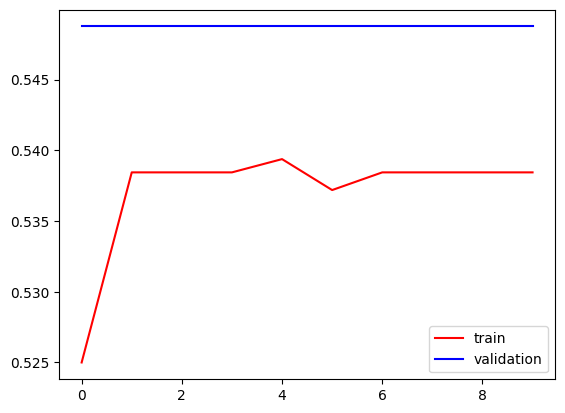

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

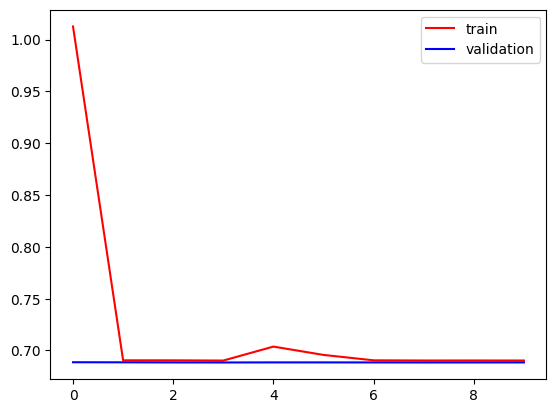

In [ ]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

In [ ]:
loss, accuracy = model.evaluate(val_data)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

In [ ]:
from tensorflow.keras.models import load_model

best_model = load_model("/content/best_underfit_solution_basic_cnn.h5")

print("Best underfitting-solution model loaded successfully.")

In [ ]:
import random
import numpy as np
from tensorflow.keras.preprocessing import image

dog_folder = "/content/data/PetImages/Dog"

dog_images = random.sample(os.listdir(dog_folder), 5)

print("Class mapping:", train_data.class_indices)

for img_name in dog_images:
    img_path = os.path.join(dog_folder, img_name)

    try:
        img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
        img_array = image.img_to_array(img)
        img_array = img_array / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        score = best_model.predict(img_array)[0][0]

        plt.imshow(img)
        plt.axis("off")
        plt.show()

        print("Image:", img_name)
        print("Raw score:", score)

        if score >= 0.5:
            print("Prediction: Dog")
        else:
            print("Prediction: Cat")

        print("-" * 40)

    except Exception as e:
        print("Skipped image:", img_name, "Error:", e)

In [ ]:
from google.colab import files

print("Class mapping:", train_data.class_indices)

uploaded = files.upload()

for file_name in uploaded.keys():
    img_path = file_name

    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    score = best_model.predict(img_array)[0][0]

    plt.imshow(img)
    plt.axis("off")
    plt.show()

    print("Raw prediction score:", score)

    if score >= 0.65:
        print("Prediction: Dog")
        print("Confidence:", round(float(score) * 100, 2), "%")

    elif score <= 0.35:
        print("Prediction: Cat")
        print("Confidence:", round(float(1 - score) * 100, 2), "%")

    else:
        print("Prediction: Uncertain")
        print("The model is not confident enough.")

In [ ]:
print(train_data.class_indices)

In [ ]:
# Install Gradio
!pip install gradio -q

import gradio as gr
import numpy as np
from PIL import Image, ImageOps
import matplotlib.pyplot as plt

# Fashion MNIST class names
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

def predict_fashion_image(uploaded_image):
    """
    This function takes an uploaded image,
    preprocesses it like Fashion MNIST,
    and predicts its class using the trained model.
    """

    # Convert uploaded image to grayscale
    img = uploaded_image.convert("L")

    # Resize image to 28x28 because Fashion MNIST images are 28x28
    img = img.resize((28, 28))

    # Invert image colors to match Fashion MNIST style
    img = ImageOps.invert(img)

    # Convert image to numpy array
    img_array = np.array(img)

    # Normalize pixel values from 0-255 to 0-1
    img_array = img_array / 255.0

    # Add batch dimension: (28, 28) becomes (1, 28, 28)
    img_input = np.expand_dims(img_array, axis=0)

    # Predict using trained model
    prediction = model.predict(img_input)

    # Get predicted class index
    predicted_index = np.argmax(prediction[0])

    # Get confidence percentage
    confidence = np.max(prediction[0]) * 100

    # Create result text
    result = f"Prediction: {class_names[predicted_index]}\nConfidence: {confidence:.2f}%"

    # Return all class probabilities also
    probabilities = {
        class_names[i]: float(prediction[0][i])
        for i in range(len(class_names))
    }

    return result, probabilities


# Create Gradio interface
demo = gr.Interface(
    fn=predict_fashion_image,
    inputs=gr.Image(type="pil", label="Upload Fashion Image"),
    outputs=[
        gr.Textbox(label="Prediction Result"),
        gr.Label(num_top_classes=10, label="Class Probabilities")
    ],
    title="Fashion MNIST Image Classifier",
    description="Upload an image of clothing, shoes, or bag. The model will predict the Fashion MNIST class."
)

# Launch app
demo.launch()